# ScopeGuard — Option B: Raw-Scope Risk Model

This notebook has two parts:

1. **Build the Option B dataset** — convert the engineered-feature dataset into
   a raw multi-hot "bag of scopes" representation (one binary column per
   OAuth scope), so the model has to learn from the scopes themselves rather
   than from hand-engineered features.
2. **Train, validate, and explain a model** on that raw-scope representation,
   using a proper train / validation / test split and a SHAP explanation of
   one prediction.

Scope binarization uses `sklearn.preprocessing.MultiLabelBinarizer` throughout
— no hand-rolled one-hot logic.

In [1]:
from collections import Counter
import json
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.preprocessing import MultiLabelBinarizer, OrdinalEncoder
from sklearn.model_selection import StratifiedKFold, cross_validate, train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, precision_score, recall_score,
)
from xgboost import XGBClassifier
import shap

import warnings
warnings.filterwarnings("ignore")

/Users/taylorland/Desktop/SURGE/scope-guard-dashboard/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Configuration

Shared constants used by both parts of the notebook.

In [2]:
RANDOM_SEED = 42

SCOPE_COLUMN = "scope_urls"
OFFLINE_COLUMN = "persistence"        # 1 = offline / refresh token requested
TARGET_COLUMN = "risk_label"
ID_COLUMN = "combination_id"

RISK_ORDER = ["Low", "Medium", "High", "Critical"]

# Carried through Option B for traceability (not model inputs)
META_COLUMNS = ["combination_id", "source_category", "source_label", "scope_urls"]

# Engineered rubric features Option B deliberately does NOT give the model
ENGINEERED_FEATURES = [
    "data_sensitivity", "access_level", "persistence", "transitive_exposure",
    "scope_count", "cross_service_breadth", "has_restricted_scope",
]

# Three-way split proportions (train is whatever remains: 0.70)
VAL_SIZE = 0.15
TEST_SIZE = 0.15


def resolve_path(filename):
    """Look in the working directory first, then /content (Colab default)."""
    if os.path.exists(filename):
        return filename
    colab_path = f"/content/{filename}"
    if os.path.exists(colab_path):
        return colab_path
    return filename  # let the failure surface naturally on read


INPUT_PATH = resolve_path("scope_guard_dataset_cleaned.csv")
OUTPUT_PATH = "scope_guard_dataset_optionB.csv"
VOCAB_PATH = "scope_vocabulary.json"
REFERENCE_PATH = "optionB_engineered_reference.csv"
SERVICE_CATALOG_PATH = resolve_path("scopes_by_service.json")

## Shared helpers

Two small, generic helpers used in both parts. Neither one binarizes
anything — that's handled by `MultiLabelBinarizer` wherever it's needed.

In [3]:
def split_scopes(cell):
    """Split a '; '-separated scope_urls cell into a clean list of scope URLs."""
    return [s.strip() for s in str(cell).split(";") if s.strip()]


def short_name(scope_url):
    """
    Turn a full scope URL into a short, readable name for columns/plots.
        https://www.googleapis.com/auth/gmail.send  ->  gmail.send
    Bare OIDC scopes (openid, profile, email) are returned unchanged.
    """
    url = scope_url.strip()
    if "/" not in url:
        return url
    name = url.rstrip("/").split("/")[-1]
    return name if name else url


def plot_y_distribution(y_data, title, risk_order):
    """Bar chart of label counts in a y-array, ordered by risk_order."""
    if y_data is None or len(y_data) == 0:
        print(f"No data to plot for {title}")
        return

    y_series = pd.Series(y_data).map(lambda x: risk_order[x])
    distribution = y_series.value_counts().reindex(risk_order).fillna(0)

    fig = plt.figure(figsize=(10, 7))
    sns.barplot(x=distribution.index, y=distribution.values, hue=distribution.index,
                palette="viridis", legend=False)
    plt.title(title, fontsize=20)
    plt.xlabel("Risk Label", fontsize=16)
    plt.ylabel("Count", fontsize=16)
    plt.xticks(fontsize=14, rotation=45, ha="right")
    plt.yticks(fontsize=14)
    plt.grid(axis="y", linestyle="--", alpha=0.7)
    plt.tight_layout()
    plt.show()
    plt.close(fig)

---
## Part 1 — Build the Option B dataset

Converts `scope_guard_dataset_cleaned.csv` into the raw-scope representation:
one binary column per scope in the vocabulary (via `MultiLabelBinarizer`),
plus `offline` and the `risk_label` target. Nothing is invented — every
binary column is derived from the `scope_urls` already present in each row.

The seven engineered features are dropped from the model inputs (that's the
whole point of Option B) but kept in a separate reference file for
cross-checking.

### 1.1 — Load the raw rows

In [4]:
raw_df = pd.read_csv(INPUT_PATH)
print(f"Loaded {len(raw_df)} rows from {INPUT_PATH}")

scope_lists = raw_df[SCOPE_COLUMN].apply(split_scopes)
raw_df[[ID_COLUMN, SCOPE_COLUMN]].head()

FileNotFoundError: [Errno 2] No such file or directory: 'scope_guard_dataset_cleaned.csv'

### 1.2 — Binarize scopes with `MultiLabelBinarizer`

`MultiLabelBinarizer` takes the list of scopes for each row and produces one
binary column per distinct scope in the vocabulary — that's the entire
multi-hot encoding step.

In [ ]:
scope_binarizer = MultiLabelBinarizer()
scope_matrix = scope_binarizer.fit_transform(scope_lists)
scope_columns = [short_name(s) for s in scope_binarizer.classes_]

# Two different scope URLs could in principle collapse to the same short name
duplicate_names = {c for c in scope_columns if scope_columns.count(c) > 1}
if duplicate_names:
    raise ValueError(f"Column-name collision(s) after shortening: {duplicate_names}")

print(f"Vocabulary: {len(scope_binarizer.classes_)} distinct scopes -> {len(scope_columns)} columns")

Vocabulary: 131 distinct scopes -> 131 columns


### 1.3 — Assemble the Option B dataframe

In [ ]:
optionB_df = raw_df[META_COLUMNS].copy()
optionB_df[scope_columns] = scope_matrix
optionB_df["offline"] = (raw_df[OFFLINE_COLUMN].astype(str).str.strip() == "1").astype(int)
optionB_df[TARGET_COLUMN] = raw_df[TARGET_COLUMN]

optionB_df.head()

,combination_id,source_category,source_label,scope_urls,email,mail.google.com,admin.datatransfer,admin.directory.domain,admin.directory.group,admin.directory.rolemanagement,...,userinfo.profile,youtube,youtube.force-ssl,youtube.readonly,youtube.upload,youtubepartner,openid,profile,offline,risk_label
0,SC-0000,Student Created,Offline access to actively monitor fitness act...,openid; profile; email; https://www.googleapis...,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,Critical
1,SC-0001,Student Created,"Full online access to YouTube account, includi...",openid; profile; email; https://www.googleapis...,1,0,0,0,0,0,...,0,1,0,0,0,0,1,1,0,High
2,SC-0002,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,High
3,SC-0003,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,1,High
4,SC-0004,Student Created,"Authentication, email adress, personalization ...",openid; profile; email; https://www.googleapis...,1,0,0,0,0,0,...,0,0,0,0,0,0,1,1,0,High


### 1.4 — Verify the encoding is faithful

Sanity checks: row count preserved, the number of 1s per row matches the
number of scopes in the original row, the `offline` flag matches the
original `persistence` column, and labels are unchanged.

In [ ]:
expected_scope_counts = scope_lists.apply(len)
actual_scope_counts = optionB_df[scope_columns].sum(axis=1)
scope_mismatches = int((expected_scope_counts.values != actual_scope_counts.values).sum())

expected_offline = (raw_df[OFFLINE_COLUMN].astype(str).str.strip() == "1").astype(int)
offline_mismatches = int((optionB_df["offline"] != expected_offline).sum())

label_mismatches = int((optionB_df[TARGET_COLUMN] != raw_df[TARGET_COLUMN]).sum())

assert len(raw_df) == len(optionB_df), "Row count changed!"

if scope_mismatches or offline_mismatches or label_mismatches:
    print(f"  {scope_mismatches} scope-count mismatches, "
          f"{offline_mismatches} offline mismatches, {label_mismatches} label mismatches")
else:
    print("All checks passed: scope counts, offline flags, and labels all match.")

All checks passed: scope counts, offline flags, and labels all match.


### 1.5 — Write outputs

In [ ]:
optionB_df.to_csv(OUTPUT_PATH, index=False)
print(f"Wrote {OUTPUT_PATH}  ({optionB_df.shape[0]} rows x {optionB_df.shape[1]} columns)")

vocab_map = dict(zip(scope_columns, scope_binarizer.classes_))
with open(VOCAB_PATH, "w", encoding="utf-8") as f:
    json.dump(
        {
            "n_scopes": len(vocab_map),
            "note": "Maps each binary column name back to its full OAuth scope URL.",
            "columns": vocab_map,
        },
        f, indent=2, sort_keys=True,
    )
print(f"Wrote {VOCAB_PATH}  ({len(vocab_map)} column -> URL mappings)")

reference_cols = [ID_COLUMN] + ENGINEERED_FEATURES + [TARGET_COLUMN]
raw_df[reference_cols].to_csv(REFERENCE_PATH, index=False)
print(f"Wrote {REFERENCE_PATH}  (engineered features kept for reference only)")

Wrote scope_guard_dataset_optionB.csv  (1843 rows x 137 columns)
Wrote scope_vocabulary.json  (131 column -> URL mappings)
Wrote optionB_engineered_reference.csv  (engineered features kept for reference only)


### 1.6 — Summary statistics

In [ ]:
total_cells = scope_matrix.size
sparsity = 100.0 * (1 - scope_matrix.sum() / total_cells)
per_row = scope_matrix.sum(axis=1)
offline_on = int(optionB_df["offline"].sum())
label_counts = optionB_df[TARGET_COLUMN].value_counts()

print("=" * 58)
print("OPTION B DATASET SUMMARY")
print("=" * 58)
print(f"  Rows:                {len(optionB_df)}")
print(f"  Scope columns:       {len(scope_columns)}")
print(f"  Model input columns: {len(scope_columns) + 1}  (scopes + offline)")
print(f"  Sparsity:            {sparsity:.1f}% zeros")
print(f"  Scopes per row:      min={per_row.min()}, max={per_row.max()}, mean={per_row.mean():.2f}")
print(f"  Offline requested:   {offline_on} rows ({offline_on / len(optionB_df) * 100:.1f}%)")

print("\n  Label distribution:")
for tier in RISK_ORDER:
    n = int(label_counts.get(tier, 0))
    print(f"    {tier:>8}: {n:>5} ({n / len(optionB_df) * 100:.1f}%)")

scope_counts = pd.Series(scope_matrix.sum(axis=0), index=scope_columns).sort_values(ascending=False)
print("\n  Most frequently requested scopes:")
for name, n in scope_counts.head(8).items():
    print(f"    {name:>34}: {int(n)}")

rare = scope_counts[scope_counts <= 2]
print(f"\n  Scopes appearing in <=2 rows: {len(rare)} (these will be hard for the model to learn)")

OPTION B DATASET SUMMARY
  Rows:                1843
  Scope columns:       131
  Model input columns: 132  (scopes + offline)
  Sparsity:            97.3% zeros
  Scopes per row:      min=1, max=9, mean=3.50
  Offline requested:   716 rows (38.8%)

  Label distribution:
         Low:   262 (14.2%)
      Medium:   536 (29.1%)
        High:   613 (33.3%)
    Critical:   432 (23.4%)

  Most frequently requested scopes:
                                openid: 418
                                 email: 414
                               profile: 397
                          spreadsheets: 184
                            gmail.send: 150
              calendar.events.readonly: 148
                 calendar.events.owned: 117
                              calendar: 113

  Scopes appearing in <=2 rows: 1 (these will be hard for the model to learn)


---
## Part 2 — Train and explain the Option B model

Uses a proper **three-way split**:

| Split | Size | Purpose |
|---|---|---|
| Train | 70% | Model fitting; 5-fold CV runs here to pick the best model |
| Validation | 15% | Intermediate checks / tuning — safe to inspect freely |
| Test | 15% | Touched **exactly once**, at the end, on the single pre-committed model |

Model selection happens on the training set only, so the test rows never
influence which model gets chosen — otherwise the final "held-out" score
would be optimistic.

Each combination is encoded as a multi-hot vector: one binary column per
scope, one binary column per Google *service* (Gmail, Drive, ...), and an
`offline` flag. All of the binarization is done with `MultiLabelBinarizer` —
no hand-rolled vocabulary/index bookkeeping.

### 2.1 — Load the dataset and encode the target

Loaded 1843 rows from scope_guard_dataset_cleaned.csv


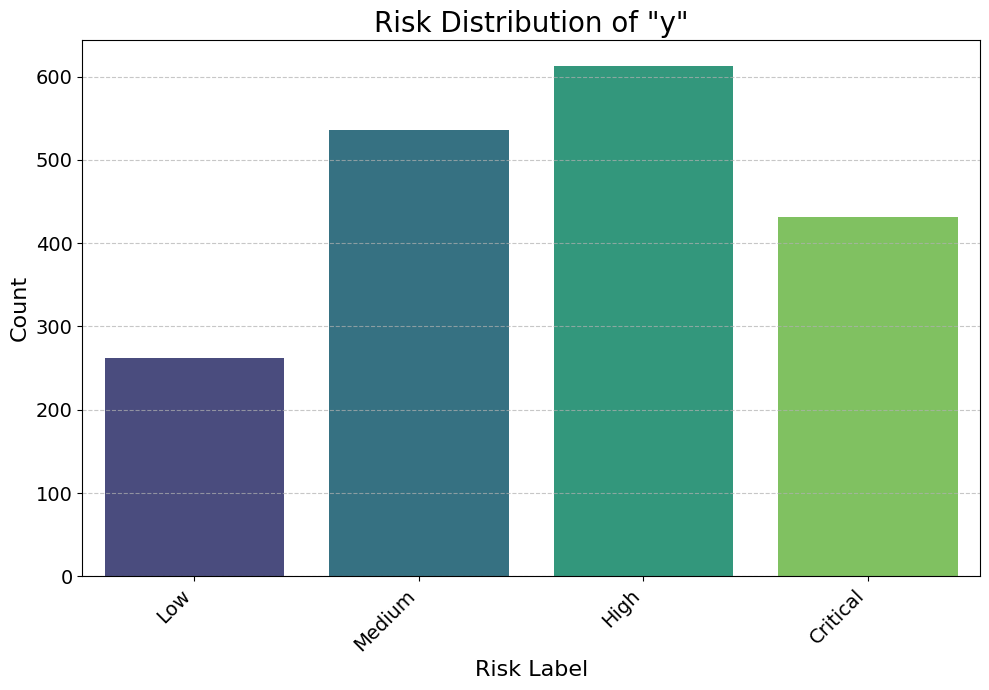

Label distribution:
  Low: 262 (14.2%)
  Medium: 536 (29.1%)
  High: 613 (33.3%)
  Critical: 432 (23.4%)


In [ ]:
DATASET_PATH = resolve_path("scope_guard_dataset_cleaned.csv")

df = pd.read_csv(DATASET_PATH)
print(f"Loaded {len(df)} rows from {DATASET_PATH}")

# OrdinalEncoder needs a 2D, single-column input plus an explicit category
# order, so it pins Low=0, Medium=1, High=2, Critical=3 exactly (rather than
# picking up whatever order the labels happen to appear in the data).
label_encoder = OrdinalEncoder(categories=[RISK_ORDER], dtype=int)
y = label_encoder.fit_transform(df[[TARGET_COLUMN]]).ravel().astype(int)

plot_y_distribution(y, 'Risk Distribution of "y"', RISK_ORDER)

print("Label distribution:")
for tier in RISK_ORDER:
    n = (df[TARGET_COLUMN] == tier).sum()
    print(f"  {tier}: {n} ({n / len(df) * 100:.1f}%)")

### 2.2 — Build the feature matrix

Two `MultiLabelBinarizer`s: one over individual scopes, one over the
services those scopes belong to (from `scopes_by_service.json`), plus the
`offline` flag. This gives the model both a fine-grained (per-scope) and a
coarse-grained (per-service) view.

In [ ]:
scope_lists = df[SCOPE_COLUMN].apply(split_scopes)

scope_binarizer = MultiLabelBinarizer()
scope_matrix = scope_binarizer.fit_transform(scope_lists)
scope_feature_names = [short_name(s) for s in scope_binarizer.classes_]
print(f"Scope vocabulary: {len(scope_binarizer.classes_)} distinct scopes")

with open(SERVICE_CATALOG_PATH, encoding="utf-8") as f:
    service_catalog = json.load(f)
scope_to_service = {s.strip(): service for service, scopes in service_catalog.items() for s in scopes}
services = sorted(service_catalog.keys())
print(f"{len(services)} services covering {len(scope_to_service)} scope URLs")

unmapped = {s for scopes in scope_lists for s in scopes if s not in scope_to_service}
if unmapped:
    print(f"  WARNING: {len(unmapped)} scopes not found in the service catalog "
          f"(no service flag set for them): {sorted(unmapped)}")

service_lists = scope_lists.apply(lambda scopes: [scope_to_service[s] for s in scopes if s in scope_to_service])
service_binarizer = MultiLabelBinarizer(classes=services)
service_matrix = service_binarizer.fit_transform(service_lists)
service_feature_names = [f"svc:{s}" for s in services]

offline_flag = (df[OFFLINE_COLUMN].astype(str).str.strip() == "1").astype(np.float32).values.reshape(-1, 1)

X = np.hstack([scope_matrix, service_matrix, offline_flag]).astype(np.float32)
feature_names = scope_feature_names + service_feature_names + ["offline"]

print(f"\nEncoded matrix: {X.shape[0]} rows x {X.shape[1]} columns ({(X == 0).mean() * 100:.1f}% zeros)")
print(f"  = {len(scope_feature_names)} scope cols + {len(service_feature_names)} service cols + offline")

Scope vocabulary: 131 distinct scopes
27 services covering 131 scope URLs

Encoded matrix: 1843 rows x 159 columns (96.2% zeros)
  = 131 scope cols + 27 service cols + offline


### 2.3 — Dataset-level diagnostic: engineered vs. raw features

This is descriptive only — it runs on the **full** dataset and selects no
model. It just contrasts the engineered encoding (a near-lookup) with the
raw-scope encoding (a genuine learning task).

In [ ]:
def compare_encodings(df, X_raw, y):
    eng_vectors = df[ENGINEERED_FEATURES].apply(tuple, axis=1).nunique()
    scope_sets = df[SCOPE_COLUMN].apply(lambda c: tuple(sorted(split_scopes(c)))).nunique()
    print(f"Unique engineered-feature vectors: {eng_vectors} / {len(df)} rows")
    print(f"Unique scope-sets:                 {scope_sets} / {len(df)} rows")
    print("(Few unique feature vectors => dense => lookup.\n"
          " Many unique scope-sets => sparse => genuine prediction.)")

    X_eng = df[ENGINEERED_FEATURES].values.astype(float)
    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
    diag_model = XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                                random_state=RANDOM_SEED, eval_metric="mlogloss")

    f1_eng = cross_validate(diag_model, X_eng, y, cv=cv, scoring="f1_macro")["test_score"].mean()
    f1_raw = cross_validate(diag_model, X_raw, y, cv=cv, scoring="f1_macro")["test_score"].mean()
    print(f"\nXGBoost macro-F1, engineered features: {f1_eng:.3f}  (near-ceiling => lookup)")
    print(f"XGBoost macro-F1, raw scopes:          {f1_raw:.3f}  (real learning problem)")


compare_encodings(df, X, y)

Unique engineered-feature vectors: 502 / 1843 rows
Unique scope-sets:                 1649 / 1843 rows
(Few unique feature vectors => dense => lookup.
 Many unique scope-sets => sparse => genuine prediction.)

XGBoost macro-F1, engineered features: 0.980  (near-ceiling => lookup)
XGBoost macro-F1, raw scopes:          0.767  (real learning problem)


### 2.4 — Three-way split (70 / 15 / 15, stratified)

Split first, so model selection can never see the validation or test rows.

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=(VAL_SIZE + TEST_SIZE), stratify=y, random_state=RANDOM_SEED,
)
relative_test_size = TEST_SIZE / (VAL_SIZE + TEST_SIZE)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=relative_test_size, stratify=y_temp, random_state=RANDOM_SEED,
)

total = len(X)
print(f"{'Set':<12}{'Rows':>7}{'%':>8}   " + "".join(f"{t:>10}" for t in RISK_ORDER))
for name, yy in [("Train", y_train), ("Validation", y_val), ("Test", y_test)]:
    counts = [int((yy == i).sum()) for i in range(len(RISK_ORDER))]
    print(f"{name:<12}{len(yy):>7}{len(yy) / total * 100:>7.1f}%   " + "".join(f"{n:>10}" for n in counts))

print("\nThe TEST set is now locked. It is not touched again until section 2.6.")

Set            Rows       %          Low    Medium      High  Critical
Train          1290   70.0%          184       375       429       302
Validation      276   15.0%           39        80        92        65
Test            277   15.0%           39        81        92        65

The TEST set is now locked. It is not touched again until section 2.6.


### 2.5 — Model selection: 5-fold CV on the training set only

In [ ]:
candidate_models = {
    "Logistic Regression": LogisticRegression(max_iter=2000, random_state=RANDOM_SEED),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_SEED),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=5, learning_rate=0.1,
                              random_state=RANDOM_SEED, eval_metric="mlogloss"),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)
cv_results = {}
for name, candidate in candidate_models.items():
    scores = cross_validate(candidate, X_train, y_train, cv=cv, scoring=["accuracy", "f1_macro"])
    cv_results[name] = {
        "accuracy": scores["test_accuracy"].mean(),
        "f1": scores["test_f1_macro"].mean(),
        "f1_std": scores["test_f1_macro"].std(),
    }
    print(f"{name}: accuracy={cv_results[name]['accuracy']:.3f}  "
          f"macro-F1={cv_results[name]['f1']:.3f} (+/- {cv_results[name]['f1_std']:.3f})")

best_name = max(cv_results, key=lambda n: cv_results[n]["f1"])
best_model = candidate_models[best_name]
print(f"\nSELECTED MODEL: {best_name} (CV macro-F1 = {cv_results[best_name]['f1']:.3f})")

Logistic Regression: accuracy=0.755  macro-F1=0.759 (+/- 0.026)
Random Forest: accuracy=0.747  macro-F1=0.751 (+/- 0.019)
XGBoost: accuracy=0.752  macro-F1=0.756 (+/- 0.017)

SELECTED MODEL: Logistic Regression (CV macro-F1 = 0.759)


### 2.6 — Fit on train, check on validation

This is the intermediate checkpoint — inspect and tune here freely; it
doesn't touch the test set.

In [ ]:
best_model.fit(X_train, y_train)

y_pred_val = best_model.predict(X_val)
print(f"Accuracy: {accuracy_score(y_val, y_pred_val):.3f}")
print(f"Macro-F1: {f1_score(y_val, y_pred_val, average='macro'):.3f}\n")
print(classification_report(y_val, y_pred_val, target_names=RISK_ORDER, zero_division=0))

Accuracy: 0.772
Macro-F1: 0.778

              precision    recall  f1-score   support

         Low       0.83      0.74      0.78        39
      Medium       0.73      0.80      0.76        80
        High       0.75      0.71      0.73        92
    Critical       0.83      0.85      0.84        65

    accuracy                           0.77       276
   macro avg       0.78      0.77      0.78       276
weighted avg       0.77      0.77      0.77       276



### 2.7 — Final test evaluation

Touched exactly once, on the single already-committed model. These are the
numbers to report.

In [ ]:
y_pred_test = best_model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred_test):.3f}")
print(f"Macro-F1: {f1_score(y_test, y_pred_test, average='macro'):.3f}\n")
print(classification_report(y_test, y_pred_test, target_names=RISK_ORDER, zero_division=0))

Accuracy: 0.762
Macro-F1: 0.773

              precision    recall  f1-score   support

         Low       0.82      0.79      0.81        39
      Medium       0.72      0.72      0.72        81
        High       0.71      0.75      0.73        92
    Critical       0.85      0.82      0.83        65

    accuracy                           0.76       277
   macro avg       0.78      0.77      0.77       277
weighted avg       0.76      0.76      0.76       277



### 2.8 — Pick one test row to explain

In [ ]:
rng = np.random.default_rng(RANDOM_SEED)
sample_idx = int(rng.integers(0, len(X_test)))
sample = X_test[sample_idx]

predicted_class = int(best_model.predict(X_test[sample_idx:sample_idx + 1])[0])
predicted_label = RISK_ORDER[predicted_class]
scopes_present = [feature_names[i] for i in range(len(feature_names)) if sample[i] == 1.0]

print(f"Test row #{sample_idx}")
print(f"Scopes present: {', '.join(scopes_present)}")
print(f"Model prediction: {predicted_label}")

Test row #24
Scopes present: email, firebase, script.deployments, script.projects, spreadsheets, openid, profile, svc:Apps Script, svc:Firebase, svc:Identity, svc:Sheets, offline
Model prediction: Critical


### 2.9 — Local SHAP explanation

Which scopes drove this particular prediction, for the top 10 by absolute
SHAP value.

In [ ]:
top_k = 10

if best_name in ("Random Forest", "XGBoost"):
    explainer = shap.TreeExplainer(best_model)
elif best_name == "Logistic Regression":
    explainer = shap.LinearExplainer(best_model, X_train)
else:
    explainer = shap.Explainer(best_model, X_train)

shap_values = explainer.shap_values(X_test[sample_idx:sample_idx + 1])

# Multiclass-safe extraction of the predicted class slice
if isinstance(shap_values, list):
    shap_vals = shap_values[predicted_class][0]
elif np.ndim(shap_values) == 3:
    shap_vals = shap_values[0, :, predicted_class]
else:
    shap_vals = shap_values[0]

ranked = sorted(zip(feature_names, shap_vals, X_test[sample_idx]), key=lambda t: -abs(t[1]))[:top_k]

print(f"Top {top_k} scope contributions toward '{predicted_label}':")
for name, val, present in ranked:
    arrow = "increases" if val > 0 else "decreases"
    tag = "present" if present == 1.0 else "absent"
    print(f"  {name:>32} ({tag:>7}): {val:+.3f} ({arrow} risk)")

Top 10 scope contributions toward 'Critical':
                      spreadsheets (present): +1.743 (increases risk)
                           offline (present): +1.460 (increases risk)
                        svc:Sheets (present): +1.266 (increases risk)
                          firebase (present): +0.736 (increases risk)
                         svc:Gmail ( absent): -0.687 (decreases risk)
                            openid (present): +0.675 (increases risk)
                   script.projects (present): +0.636 (increases risk)
                      svc:Firebase (present): +0.511 (increases risk)
                           profile (present): +0.469 (increases risk)
                         svc:Drive ( absent): -0.271 (decreases risk)


### 2.10 — Plot the SHAP explanation

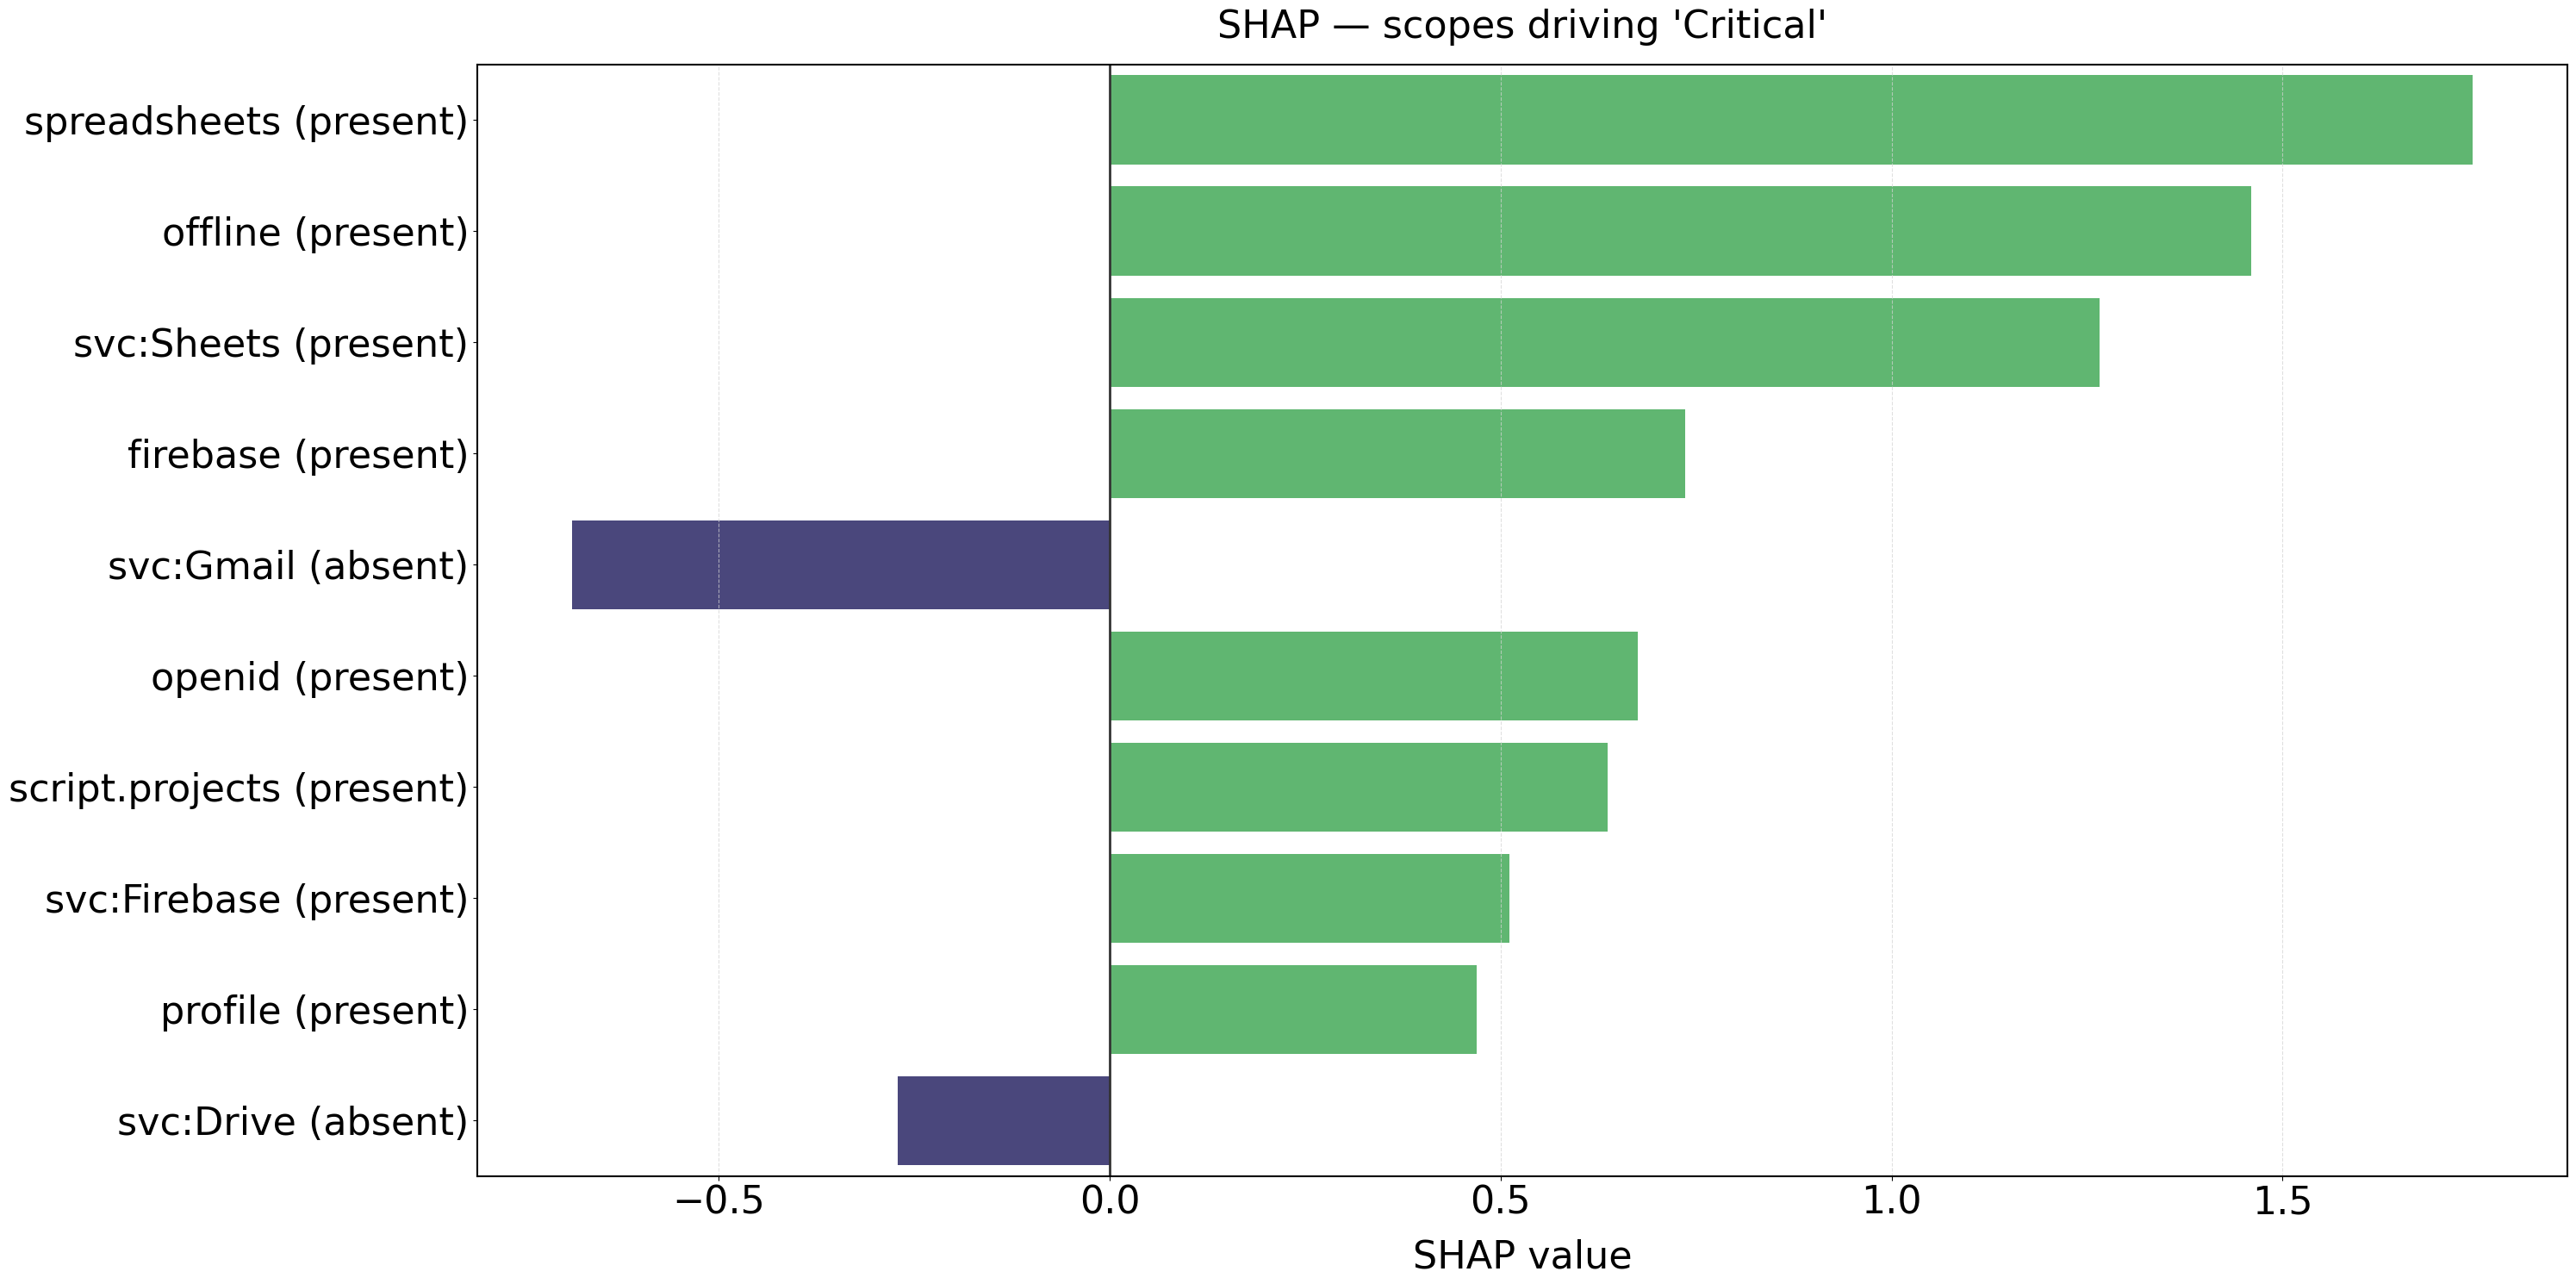

Saved: shap_scope_explanation.png


In [ ]:
# Poster sizing: 10 horizontal bars with long labels at 32pt need a wide
# canvas, otherwise the y-labels eat the plotting area and squash the bars.
POSTER_FONTSIZE = 32
fig, ax = plt.subplots(figsize=(30, 15))

# `ranked` is already sorted by descending absolute SHAP value; seaborn draws
# the first category at the top, so passing it as-is puts the largest
# magnitude at the top regardless of sign.
names = [f"{t[0]} ({'present' if t[2] == 1.0 else 'absent'})" for t in ranked]
scores = [float(t[1]) for t in ranked]

viridis = sns.color_palette("viridis", n_colors=10)
pos_color, neg_color = viridis[7], viridis[1]
colors = [pos_color if s > 0 else neg_color for s in scores]

sns.barplot(x=scores, y=names, hue=names, palette=colors, dodge=False, legend=False, ax=ax, orient="h")
ax.set_yticks(np.arange(len(names)))
ax.set_yticklabels(names, fontsize=POSTER_FONTSIZE)
ax.tick_params(axis="x", labelsize=POSTER_FONTSIZE)
ax.axvline(0, color="#333", linewidth=2.0)
ax.set_xlabel("SHAP value", fontsize=POSTER_FONTSIZE, labelpad=14)
ax.set_title(f"SHAP — scopes driving '{predicted_label}'", fontsize=POSTER_FONTSIZE, pad=22)
ax.grid(axis="x", linestyle="--", alpha=0.7, color="lightgrey")
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

plt.tight_layout()
# dpi 300 for print; 150 looks soft when blown up to poster scale.
plt.savefig("shap_scope_explanation.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: shap_scope_explanation.png")

### 2.11 — Model performance metrics

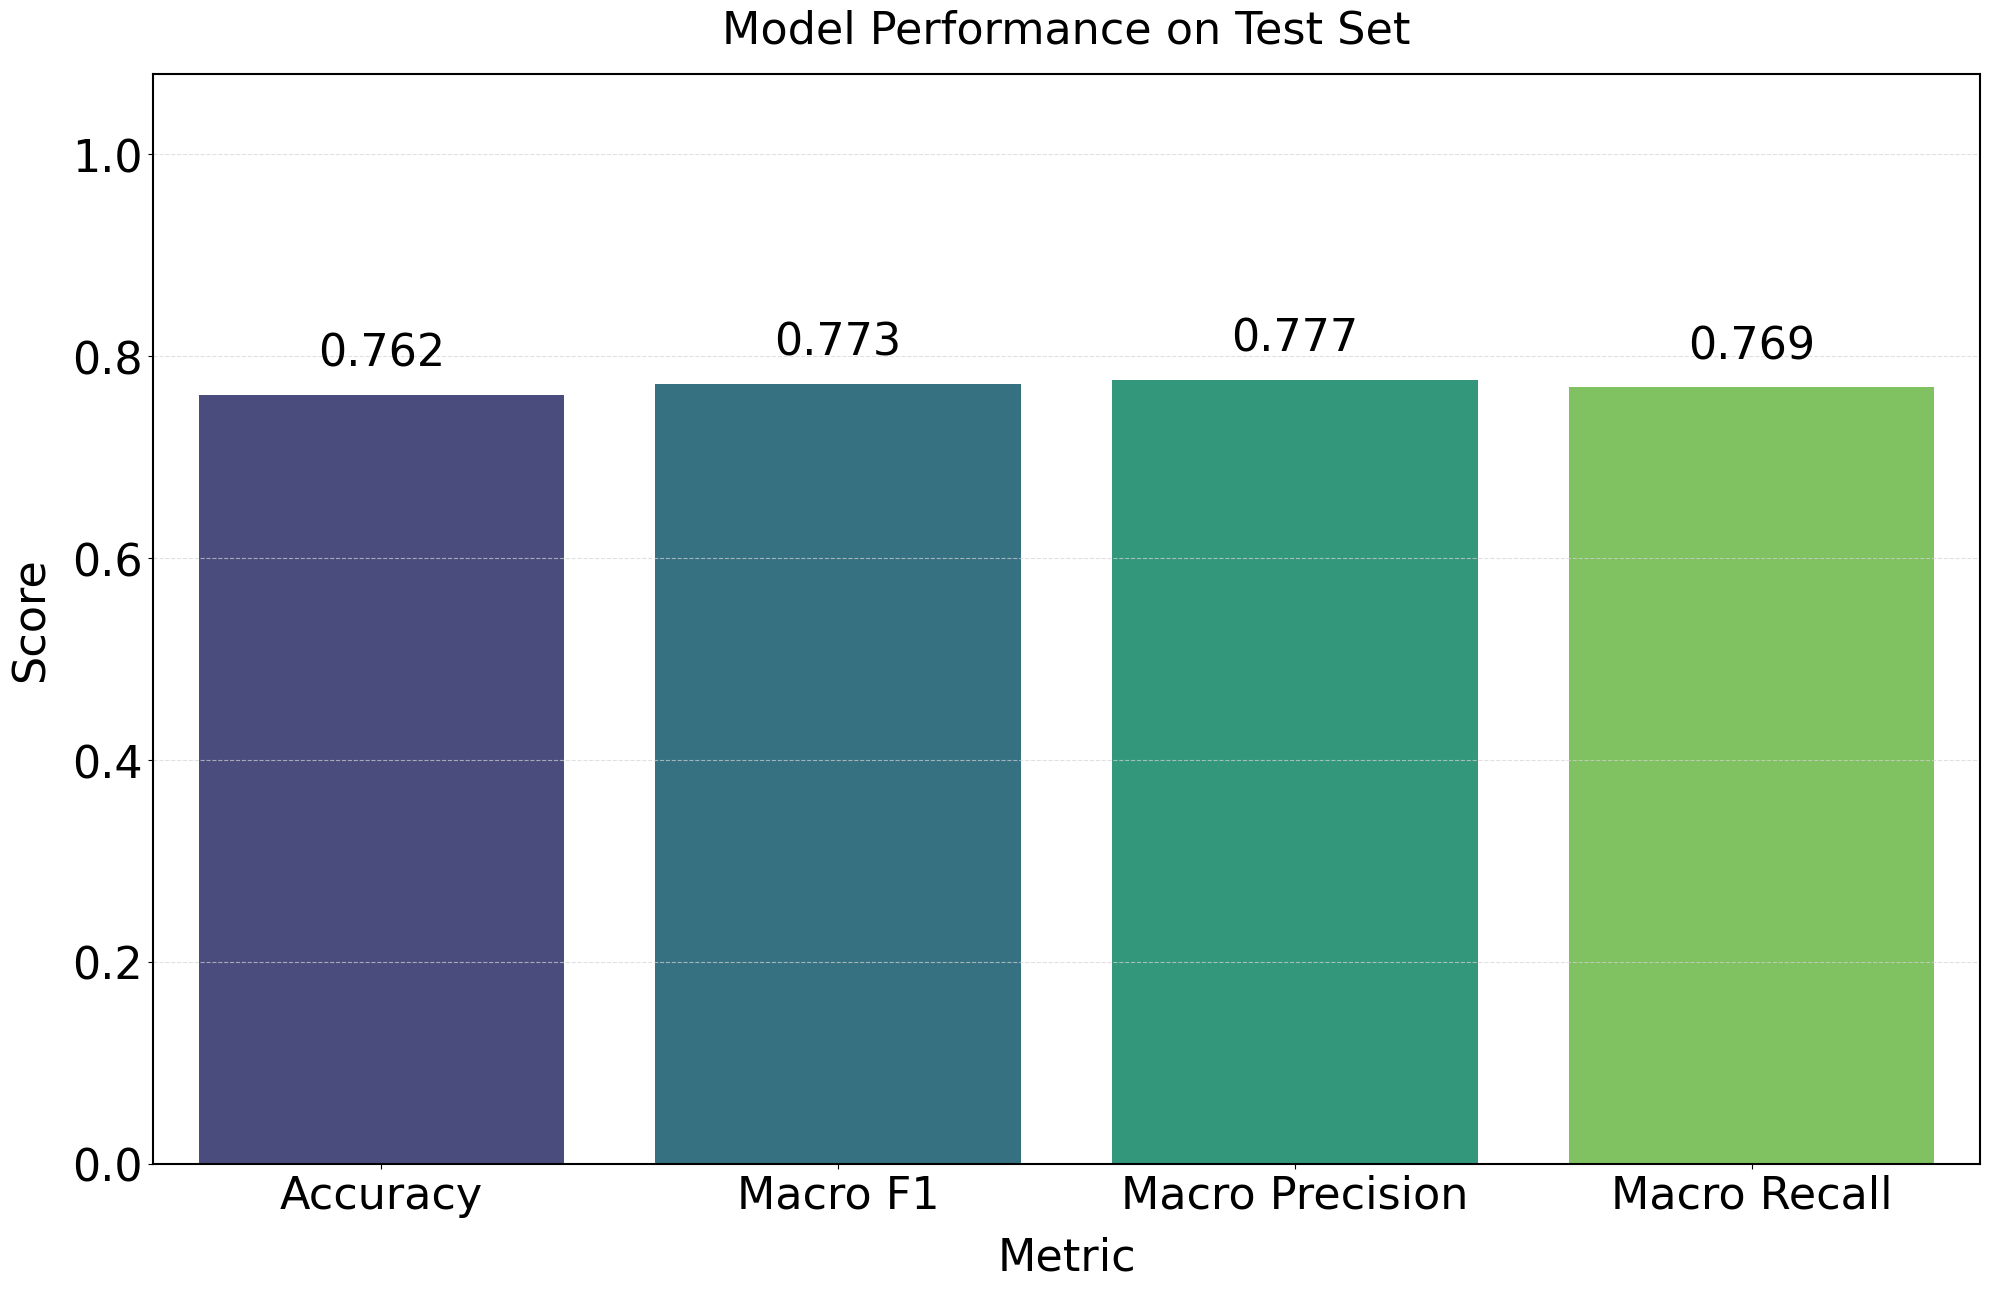

Saved: model_performance_metrics.png


In [ ]:
accuracy = accuracy_score(y_test, y_pred_test)
f1_macro = f1_score(y_test, y_pred_test, average="macro", zero_division=0)
precision_macro = precision_score(y_test, y_pred_test, average="macro", zero_division=0)
recall_macro = recall_score(y_test, y_pred_test, average="macro", zero_division=0)

metrics_df = pd.DataFrame({
    "Metric": ["Accuracy", "Macro F1", "Macro Precision", "Macro Recall"],
    "Score": [accuracy, f1_macro, precision_macro, recall_macro],
})

POSTER_FONTSIZE = 32
fig, ax = plt.subplots(figsize=(20, 13))
sns.barplot(x="Metric", y="Score", data=metrics_df, hue="Metric", palette="viridis",
            dodge=False, legend=False, ax=ax)

ax.set_title("Model Performance on Test Set", fontsize=POSTER_FONTSIZE, pad=22)
ax.set_xlabel("Metric", fontsize=POSTER_FONTSIZE, labelpad=14)
ax.set_ylabel("Score", fontsize=POSTER_FONTSIZE, labelpad=14)
ax.set_ylim(0, 1.08)  # headroom so the value labels aren't clipped
ax.tick_params(axis="x", labelsize=POSTER_FONTSIZE)
ax.tick_params(axis="y", labelsize=POSTER_FONTSIZE)
ax.grid(axis="y", linestyle="--", alpha=0.7, color="lightgrey")
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

for i, row in metrics_df.iterrows():
    ax.text(i, row["Score"] + 0.02, f"{row['Score']:.3f}", ha="center", va="bottom", fontsize=POSTER_FONTSIZE)

plt.tight_layout()
plt.savefig("model_performance_metrics.png", dpi=300, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: model_performance_metrics.png")

### 2.12 — Confusion matrix

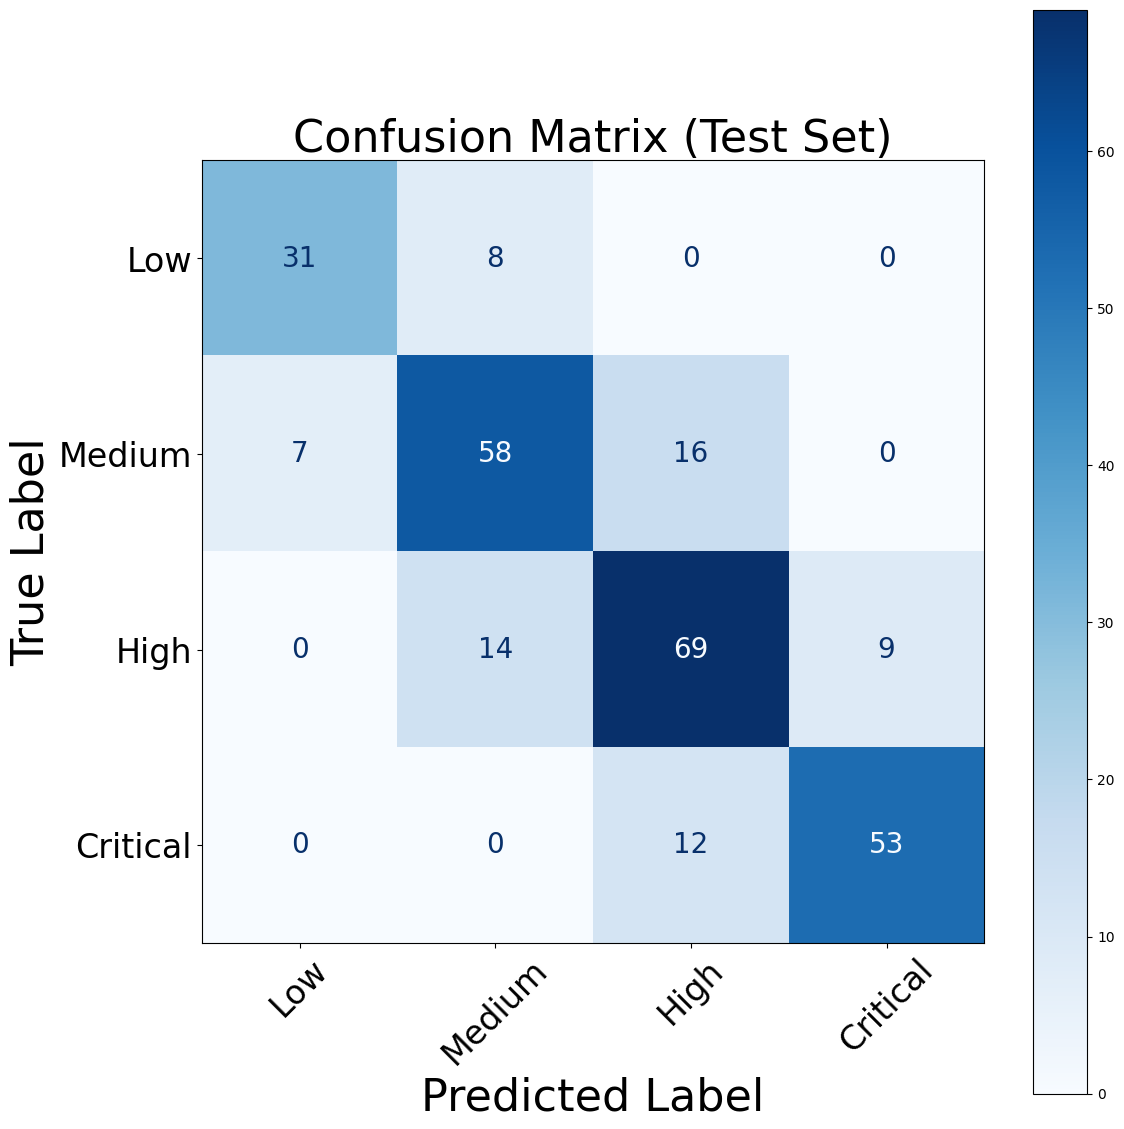

Saved: confusion_matrix.png


In [ ]:
cm = confusion_matrix(y_test, y_pred_test, labels=np.arange(len(RISK_ORDER)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=RISK_ORDER)

fig, ax = plt.subplots(figsize=(12, 12))
disp.plot(cmap=plt.cm.Blues, ax=ax, values_format="d")

ax.set_title("Confusion Matrix (Test Set)", fontsize=32)
ax.set_xlabel("Predicted Label", fontsize=32)
ax.set_ylabel("True Label", fontsize=32)
ax.tick_params(axis="x", labelsize=24, rotation=45)
ax.tick_params(axis="y", labelsize=24, rotation=0)
for labels in disp.text_:
    for label in labels:
        label.set_fontsize(20)

plt.tight_layout()
plt.savefig("confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: confusion_matrix.png")

### 2.13 — True label distribution in the test set

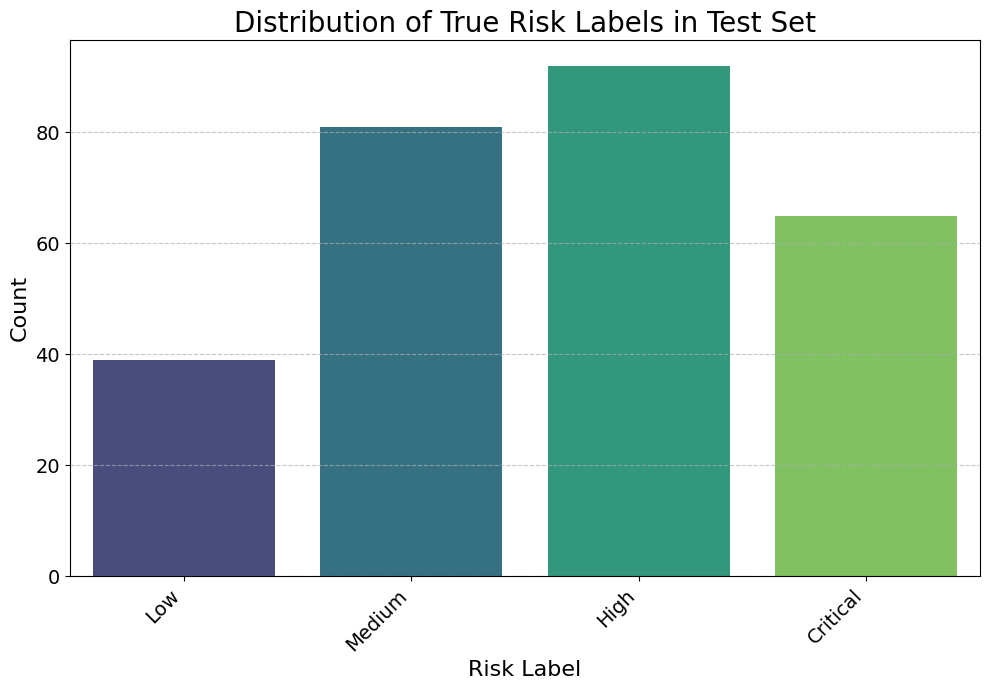

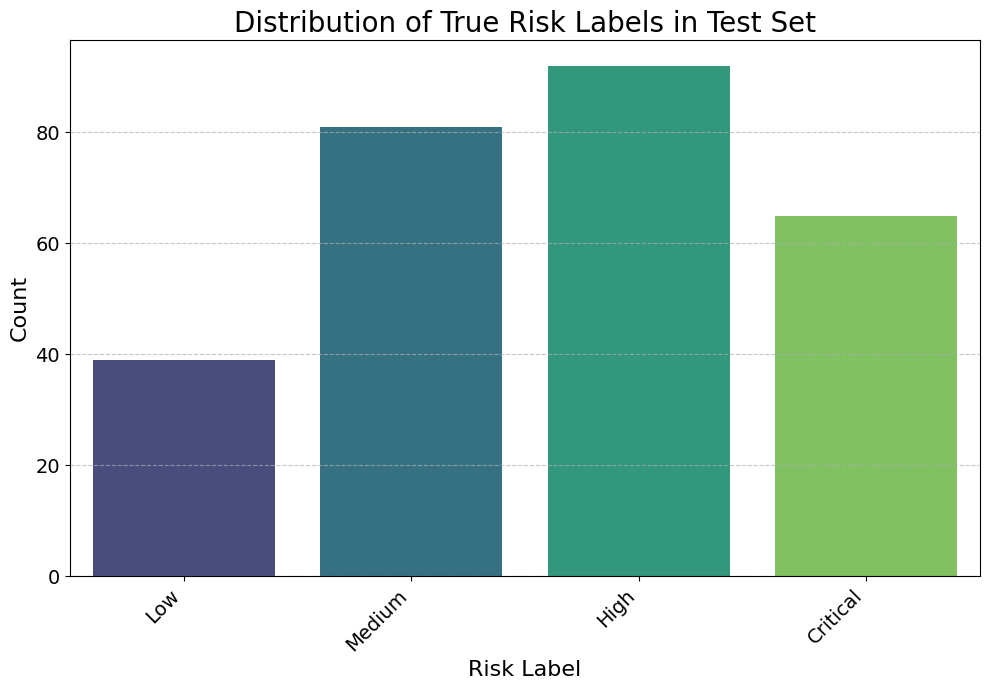

Saved: y_test_distribution.png


In [ ]:
plot_y_distribution(y_test, "Distribution of True Risk Labels in Test Set", RISK_ORDER)

fig = plt.figure(figsize=(10, 7))
y_test_series = pd.Series(y_test).map(lambda x: RISK_ORDER[x])
distribution = y_test_series.value_counts().reindex(RISK_ORDER)
sns.barplot(x=distribution.index, y=distribution.values, hue=distribution.index,
            palette="viridis", legend=False)
plt.title("Distribution of True Risk Labels in Test Set", fontsize=20)
plt.xlabel("Risk Label", fontsize=16)
plt.ylabel("Count", fontsize=16)
plt.xticks(fontsize=14, rotation=45, ha="right")
plt.yticks(fontsize=14)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.tight_layout()
plt.savefig("y_test_distribution.png", dpi=150, bbox_inches="tight")
plt.show()
plt.close(fig)
print("Saved: y_test_distribution.png")

### 2.14 — Save the model and supporting artifacts

In [ ]:
joblib.dump(best_model, "model.joblib")
print("Trained model saved to model.joblib")

joblib.dump(scope_binarizer, "scope_binarizer.pkl")
print("Feature names saved to scope_binarizer.pkl")

X_train_df = pd.DataFrame(X_train, columns=feature_names)
X_train_df.to_csv("X_train.csv", index=False)

y_train_df = pd.DataFrame(y_train, columns=[TARGET_COLUMN])
y_train_df.to_csv("y_train.csv", index=False)

print("Saved X_train.csv and y_train.csv")

Trained model saved to model.joblib
Feature names saved to scope_binarizer.pkl
Saved X_train.csv and y_train.csv
